In [1]:
using NPZ
pixel = 1000
data = npzread("data/pixels_void_offcentre_20/dA_pixel_$pixel.npz")

z_range = data["z_range"]
dA = data["dA"]
dA_z = data["dA_z"]
dA_zz = data["dA_zz"]
dA_zzz = data["dA_zzz"]

2001-element Vector{Float64}:
     1.393279910759247e8
     1.3748127784906012e8
     1.3555816142316884e8
     1.337617227248788e8
     1.3190592150635488e8
     1.3017593045916058e8
     1.2838503103289212e8
     1.2671853824899459e8
     1.249894469678034e8
     1.2338383509051533e8
     ⋮
 28041.920933890273
 28040.878941327708
 28039.83697435998
 28038.795033184597
 28037.753117482156
 28036.711228815824
 28035.669364726986
 28034.627527491197
 28033.585715620888

In [2]:
using Plots
using LaTeXStrings
plot(z_range, dA, label="Exact", lw=2)
function dA_exp(z)
    z_eval = round(Int, z *1e5 + 1)
    return @. dA[z_eval] + dA_z[z_eval] * (z_range-z) + 0.5 * dA_zz[z_eval] * (z_range-z)^2 + (1/6) * dA_zzz[z_eval] * (z_range-z)^3
end

plot!(z_range, dA_exp(0.000), label="z*=0.000", lw=2, ls=:dash)
#plot!(z_range, dA_exp(0.007), label="z*=0.007", lw=2, ls=:dash)
#plot!(z_range, dA_exp(0.008), label="z*=0.008", lw=2, ls=:dash)
plot!(z_range, dA_exp(0.005), label="z*=0.005", lw=2, ls=:dot)
plot!(z_range, dA_exp(0.010), label="z*=0.010", lw=2, ls=:dashdot)
plot!(z_range, dA_exp(0.015), label="z*=0.015", lw=2, ls=:dashdotdot)
xlabel!(L"z")
ylabel!(L"d_A")
title!(L"d_A" * " and expansion for fiducial light ray")
xlims!(0, 0.020)
ylims!(0, 80)
Plots.savefig("plots/fiducial_ray.pdf")

"/home/jbb/Documents/cosmography/plots/fiducial_ray.pdf"

In [7]:
using Plots
using LaTeXStrings
plot(z_range, dA./dA, label="Exact", lw=2)
function dA_exp(z)
    z_eval = round(Int, z *1e5 + 1)
    return @. dA[z_eval] + dA_z[z_eval] * (z_range-z) + 0.5 * dA_zz[z_eval] * (z_range-z)^2 + (1/6) * dA_zzz[z_eval] * (z_range-z)^3
end

plot!(z_range, dA_exp(0.000)./dA, label="z*=0.000", lw=2, ls=:dash)
#plot!(z_range, dA_exp(0.007)./dA, label="z*=0.007", lw=2, ls=:dash)
#plot!(z_range, dA_exp(0.008)./dA, label="z*=0.008", lw=2, ls=:dash)
plot!(z_range, dA_exp(0.005)./dA, label="z*=0.005", lw=2, ls=:dot)
plot!(z_range, dA_exp(0.010)./dA, label="z*=0.010", lw=2, ls=:dashdot)
plot!(z_range, dA_exp(0.015)./dA, label="z*=0.015", lw=2, ls=:dashdotdot)
xlabel!(L"z")
ylabel!(L"d_A/d_{A,\mathrm{exact}}")
title!(L"d_A" * " and expansion for fiducial light ray")
xlims!(0, 0.020)
ylims!(-1, 3)
Plots.savefig("plots/fiducial_ray_norm.pdf")

"/home/jbb/Documents/cosmography/plots/fiducial_ray_norm.pdf"

In [ ]:
using Healpix, NPZ

Nside = 64
npix  = nside2npix(Nside)

# Load first pixel to get size
data0   = npzread("data/pixels_void_offcentre_20/dA_pixel_1.npz")
z_range = data0["z_range"]
nz      = length(z_range)

# Store all data: (pixel, redshift)
dA_map = zeros(Float64, npix, nz)
dA_z_map = zeros(Float64, npix, nz)
dA_zz_map = zeros(Float64, npix, nz)
dA_zzz_map = zeros(Float64, npix, nz)

# Fill array
for pixel in 1:npix
    data = npzread("data/pixels_void_offcentre_20/dA_pixel_$pixel.npz")
    dA_map[pixel, :] = data["dA"]
    dA_z_map[pixel, :] = data["dA_z"]
    dA_zz_map[pixel, :] = data["dA_zz"]
    dA_zzz_map[pixel, :] = data["dA_zzz"]
end

In [ ]:
pplot = plot(z_range, dA_map[1, :], lw = 0, legend = false)
for pixel in 1:100:npix
    plot!(
        z_range,
        dA_map[pixel, :],
        lw = 1,
        ls = :dash,
        color = :gray
    )
end
display(pplot)

In [ ]:
using CairoMakie
using Printf
# Updated function to remove the implicit '+' from exponents
function clean_tex(val)
    s = @sprintf("%.3g", val)
    if contains(s, 'e')
        # This regex matches 'e', then an optional '+', then any number of '0's, 
        # then captures the actual exponent digits. It keeps '-' if present.
        s = replace(s, r"e\+?(-?)0*(\d+)" => s" \\times 10^{\1\2}")
    end
    return s
end

function plot_sky(str_type, z_val, map_data)
    str_z     = @sprintf("%.3f", z_val) # Forces exactly 3 digits
    # Figure with 5px padding
    fig = Figure(size = (600, 360), figure_padding = 10)
    
    map_min, map_max = extrema(map_data.pixels)
    img, _, _ = Healpix.mollweide(map_data)
    
    gl = fig[1, 1] = GridLayout(tellwidth = true)
    
    # Row 1: Map
    ax = Axis(gl[1, 1], aspect = DataAspect())
    hidedecorations!(ax)
    hidespines!(ax)
    hm = Makie.heatmap!(ax, img', colormap = :viridis, nan_color = :transparent, colorrange = (map_min, map_max), rasterize = 3.0)
    tightlimits!(ax)
    
    # Row 2: Colorbar
    cb = Makie.Colorbar(gl[2, 1], hm, 
        vertical = false, 
        ticks = [map_min + 1e-6*abs(map_min), map_max - 1e-6*abs(map_max)], 
        ticklabelsvisible = false, 
        ticksize = 12, 
        tickalign = 0.0, 
        width = Relative(1.0)
    )
    
    # Row 3: The "Clean Look" Labels (Now without the + sign)
    Label(gl[3, 1], L"%$((clean_tex(map_min)))", halign = :left,   fontsize = 30, tellwidth = false)
    Label(gl[3, 1], L"%$str_type(z=%$str_z)", halign = :center, fontsize = 36, tellwidth = false)
    Label(gl[3, 1], L"%$((clean_tex(map_max)))", halign = :right,  fontsize = 30, tellwidth = false)
    
    # Layout Locks
    rowsize!(gl, 1, Aspect(1, 0.5)) 
    rowgap!(gl, 1, 0) # 0px gap between map and bar
    rowgap!(gl, 2, 2)  # 2px gap between bar and text
    
    # Crop and Save
    resize_to_layout!(fig)
    save("plots/$str_type"*"_$(Int(z_val*1000)).pdf", fig)
    
    display(fig)
end

In [ ]:
z_vals = [0.001, 0.004, 0.008, 0.012, 0.020]
for z_val in z_vals
    map = HealpixMap{Float64, NestedOrder}(Nside)
    map[:] = dA_map[:, Int(z_val*1e5 + 1)]
    plot_sky("d_A", z_val, map)
end
for z_val in z_vals
    map = HealpixMap{Float64, NestedOrder}(Nside)
    map[:] = dA_z_map[:, Int(z_val*1e5 + 1)]
    plot_sky("d_A'", z_val, map)
end
for z_val in z_vals
    map = HealpixMap{Float64, NestedOrder}(Nside)
    map[:] = dA_zz_map[:, Int(z_val*1e5 + 1)]
    plot_sky("d_A''", z_val, map)
end
for z_val in z_vals
    map = HealpixMap{Float64, NestedOrder}(Nside)
    map[:] = dA_zzz_map[:, Int(z_val*1e5 + 1)]
    plot_sky("d_A'''", z_val, map)
end

In [ ]:
using Statistics

plot(z_range, mean(dA_map, dims=1)[:])


In [ ]:
function dA_exp_fixed(z, iz0)
    z0 = z_range[iz0]                # expansion point
    Δz = z - z0                       # distance from expansion

    # pick derivatives at expansion point
    dA_     = dA_map[:, iz0]
    dA_z_   = dA_z_map[:, iz0]
    dA_zz_  = dA_zz_map[:, iz0]
    dA_zzz_ = dA_zzz_map[:, iz0]

    # evaluate Taylor expansion
    return @. dA_ + dA_z_ * Δz + 0.5 * dA_zz_ * Δz^2 + (1/6) * dA_zzz_ * Δz^3
end

full_map = zeros(Float64, npix, nz)
gap = 1 # gap = 0.001
for (i, z) in enumerate(z_range)
    bin = floor(Int, (z + 0.0005*gap) / (0.001*gap))
    println("z = $z, bin = $bin")
    iz0 = 1 + gap*100 * bin
    full_map[:, i] = dA_exp_fixed(z, iz0)
end

In [ ]:
gr()  # or try pyplot()

Plots.default(
    fontfamily = "Computer Modern",
    guidefont = font(12, "Computer Modern"),
    tickfont = font(10, "Computer Modern"),
    legendfont = font(10, "Computer Modern")
)

using Statistics
Plots.plot(z_range, mean((dA_map .- full_map)./ dA_map, dims=1)[:], label=L"\mathrm{Mean}",left_margin = 3Plots.mm)
Plots.plot!(z_range, mean((dA_map .- full_map)./ dA_map, dims=1)[:]+ sqrt.(var((dA_map .- full_map)./ dA_map, dims=1)[:]), linestyle=:dash, label=L"\mathrm{Mean} + 1\sigma")
Plots.plot!(z_range, mean((dA_map .- full_map)./ dA_map, dims=1)[:]- sqrt.(var((dA_map .- full_map)./ dA_map, dims=1)[:]), linestyle=:dash, label=L"\mathrm{Mean} - 1\sigma")
Plots.ylims!(-.1, .1)
Plots.xlabel!("z")
Plots.ylabel!(L"\frac{d_A - d_{A,\mathrm{expansion}}}{d_A}")
Plots.title!("Relative error of expansion ($(Int(20 / gap + 1)) redshifts)")
Plots.savefig("plots/relative_error$(Int(20 / gap + 1)).pdf")

In [ ]:
Plots.plot(z_range, (dA_map[801, :] .- full_map[801, :])./ dA_map[801, :])
Plots.ylims!(-.01, .01)

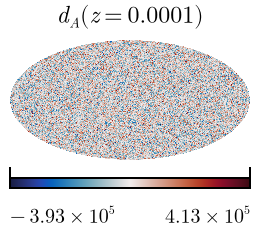

CairoMakie.Screen{IMAGE}


In [11]:
function clean_tex(val)
    s = @sprintf("%.3g", val)
    if contains(s, 'e')
        s = replace(s, r"e\+?(-?)0*(\d+)" => s" \\times 10^{\1\2}")
    end
    return s
end

function plot_sky(z_val, map_data)
    str_z = @sprintf("%.3f", z_val)
    fig = Figure(size = (130, 115), figure_padding = 5)
    
    map_min, map_max = extrema(map_data.pixels)
    img, _, _ = Healpix.mollweide(map_data)
    
    gl = fig[1, 1] = GridLayout(tellwidth = true)
    
    # Generate the title string
    title_str = z_val == 0.0 ? L"d_A" : L"d_A(z=0.0001)"
    
    # ROW 1: The Title
    Label(gl[1, 1], title_str, halign = :center, fontsize = 12, tellwidth = false)
    
    # ROW 2: The Map
    ax = CairoMakie.Axis(gl[2, 1], aspect = DataAspect())
    hidedecorations!(ax)
    hidespines!(ax)
    
    cmap = (map_min < 0 && map_max > 0) ? :balance : :viridis
    hm = Makie.heatmap!(ax, img', colormap = cmap, nan_color = :transparent, colorrange = (map_min, map_max), rasterize = 3.0)
    tightlimits!(ax)
    
    # ROW 3: The Colorbar
    Makie.Colorbar(gl[3, 1], hm, 
        vertical = false, 
        ticks = [map_min + 1e-6*abs(map_min), map_max - 1e-6*abs(map_max)], 
        ticklabelsvisible = false, 
        height = 5, 
        tickalign = 0.0, 
        width = Relative(1.0)
    )
    
    # ROW 4: The Min / Max Labels
    Label(gl[4, 1], L"%$((clean_tex(map_min)))", halign = :left,   fontsize = 10, tellwidth = false)
    Label(gl[4, 1], L"%$((clean_tex(map_max)))", halign = :right,  fontsize = 10, tellwidth = false)
    
    # Adjust layout locks for the new rows
    rowsize!(gl, 2, Aspect(1, 0.5)) # Lock the map (now in row 2) aspect ratio
    rowgap!(gl, 1, 5) # Gap between Title and Map
    rowgap!(gl, 2, 4) # Gap between Map and Colorbar
    rowgap!(gl, 3, 8) # Gap between Colorbar and Min/Max labels
    display(fig)
end

NSIDE = 64
NPIX  = nside2npix(NSIDE)
map_data = HealpixMap{Float64, NestedOrder}(NSIDE)
map_data.pixels .= randn(NPIX) .* 1e5
plot_sky(0.0001, map_data)
